In [161]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

### Auditoria e limpeza

In [79]:
df = pd.read_csv('../Sleep_health_and_lifestyle_dataset.csv')

In [80]:
print(df.head())
print(df.tail())

   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80          75      

In [81]:
df = df.drop(columns='Person ID')

In [82]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Blood Pressure           374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 35.2+ KB
None


In [83]:
print(df.describe(include=['object', 'float64', 'int64']))

       Gender         Age Occupation  Sleep Duration  Quality of Sleep  \
count     374  374.000000        374      374.000000        374.000000   
unique      2         NaN         11             NaN               NaN   
top      Male         NaN      Nurse             NaN               NaN   
freq      189         NaN         73             NaN               NaN   
mean      NaN   42.184492        NaN        7.132086          7.312834   
std       NaN    8.673133        NaN        0.795657          1.196956   
min       NaN   27.000000        NaN        5.800000          4.000000   
25%       NaN   35.250000        NaN        6.400000          6.000000   
50%       NaN   43.000000        NaN        7.200000          7.000000   
75%       NaN   50.000000        NaN        7.800000          8.000000   
max       NaN   59.000000        NaN        8.500000          9.000000   

        Physical Activity Level  Stress Level BMI Category Blood Pressure  \
count                374.000000   

Analisando colunas categóricas:

In [84]:
print(df['Gender'].value_counts())

Gender
Male      189
Female    185
Name: count, dtype: int64


In [85]:
print(df['Occupation'].value_counts())

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64


In [86]:
print(df['BMI Category'].value_counts())

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64


In [87]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna("No") # Preenche os valores ausentes
print(df['Sleep Disorder'].value_counts())

Sleep Disorder
No             219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


In [88]:
# Padronizando o BMI
mapping = {'Normal Weight': 'Normal',
           'Overweight': 'Above Normal',
           'Obese': 'Above Normal'
}
df['BMI Category'] = df['BMI Category'].replace(mapping)

# Agrupando Occupation
mapping = {
    'Nurse': 'Healthcare',
    'Doctor': 'Healthcare',
    'Engineer': 'STEM_Education',
    'Teacher': 'STEM_Education',
    'Software Engineer': 'STEM_Education',
    'Scientist': 'STEM_Education',
    'Lawyer': 'Corporate_Sales',
    'Accountant': 'Corporate_Sales',
    'Salesperson': 'Corporate_Sales',
    'Manager': 'Corporate_Sales',
    'Sales Representative': 'Corporate_Sales'
}
df['Occupation'] = df['Occupation'].map(mapping)

In [89]:
# Dividindo Blood Pressure em duas colunas numéricas
bp_split = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic_BP'] = bp_split[0].astype(int)
df['Diastolic_BP'] = bp_split[1].astype(int)

df.drop(columns=['Blood Pressure'], inplace=True)

In [90]:
print(f"Linhas duplicadas: {df.duplicated().sum()}")
df = df.drop_duplicates()

Linhas duplicadas: 242


In [91]:
print(df.head())

  Gender  Age       Occupation  Sleep Duration  Quality of Sleep  \
0   Male   27   STEM_Education             6.1                 6   
1   Male   28       Healthcare             6.2                 6   
3   Male   28  Corporate_Sales             5.9                 4   
5   Male   28   STEM_Education             5.9                 4   
6   Male   29   STEM_Education             6.3                 6   

   Physical Activity Level  Stress Level  BMI Category  Heart Rate  \
0                       42             6  Above Normal          77   
1                       60             8        Normal          75   
3                       30             8  Above Normal          85   
5                       30             8  Above Normal          85   
6                       40             7  Above Normal          82   

   Daily Steps Sleep Disorder  Systolic_BP  Diastolic_BP  
0         4200             No          126            83  
1        10000             No          125          

In [92]:
df.to_csv('cleaned_health_data.csv', index=False)

### Extração de insights

In [93]:
df = pd.read_csv('cleaned_health_data.csv')


In [94]:
print(df.describe(include=['object', 'float64', 'int64']))

       Gender         Age  Occupation  Sleep Duration  Quality of Sleep  \
count     132  132.000000         132      132.000000        132.000000   
unique      2         NaN           3             NaN               NaN   
top      Male         NaN  Healthcare             NaN               NaN   
freq       67         NaN          53             NaN               NaN   
mean      NaN   41.128788         NaN        7.082576          7.151515   
std       NaN    8.813942         NaN        0.775335          1.269037   
min       NaN   27.000000         NaN        5.800000          4.000000   
25%       NaN   33.750000         NaN        6.400000          6.000000   
50%       NaN   41.000000         NaN        7.150000          7.000000   
75%       NaN   49.000000         NaN        7.725000          8.000000   
max       NaN   59.000000         NaN        8.500000          9.000000   

        Physical Activity Level  Stress Level BMI Category  Heart Rate  \
count                132.

In [95]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   132 non-null    object 
 1   Age                      132 non-null    int64  
 2   Occupation               132 non-null    object 
 3   Sleep Duration           132 non-null    float64
 4   Quality of Sleep         132 non-null    int64  
 5   Physical Activity Level  132 non-null    int64  
 6   Stress Level             132 non-null    int64  
 7   BMI Category             132 non-null    object 
 8   Heart Rate               132 non-null    int64  
 9   Daily Steps              132 non-null    int64  
 10  Sleep Disorder           132 non-null    object 
 11  Systolic_BP              132 non-null    int64  
 12  Diastolic_BP             132 non-null    int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 13.5+ KB
None


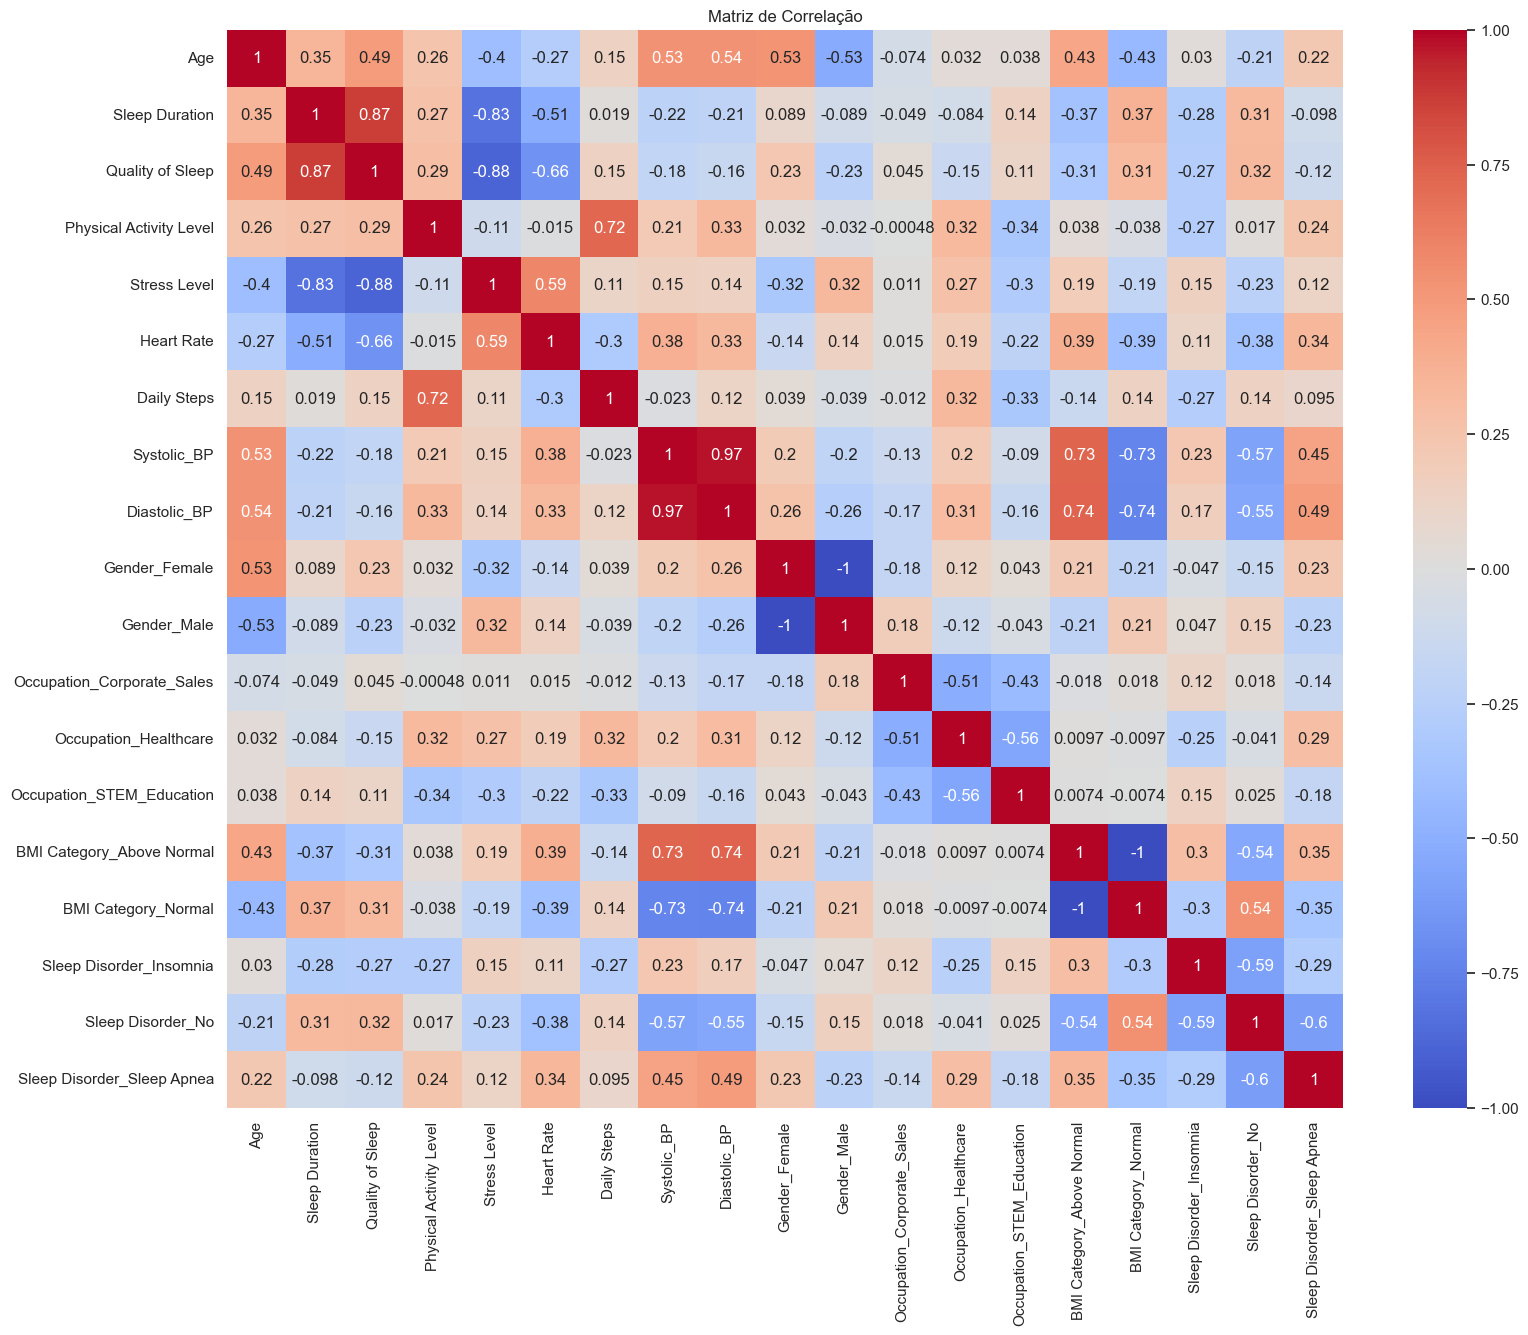

In [96]:
df_encoded = pd.get_dummies(df, drop_first=False)

corr = df_encoded.corr()

plt.figure(figsize=(18,14))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True)
plt.title("Matriz de Correlação")
plt.show()

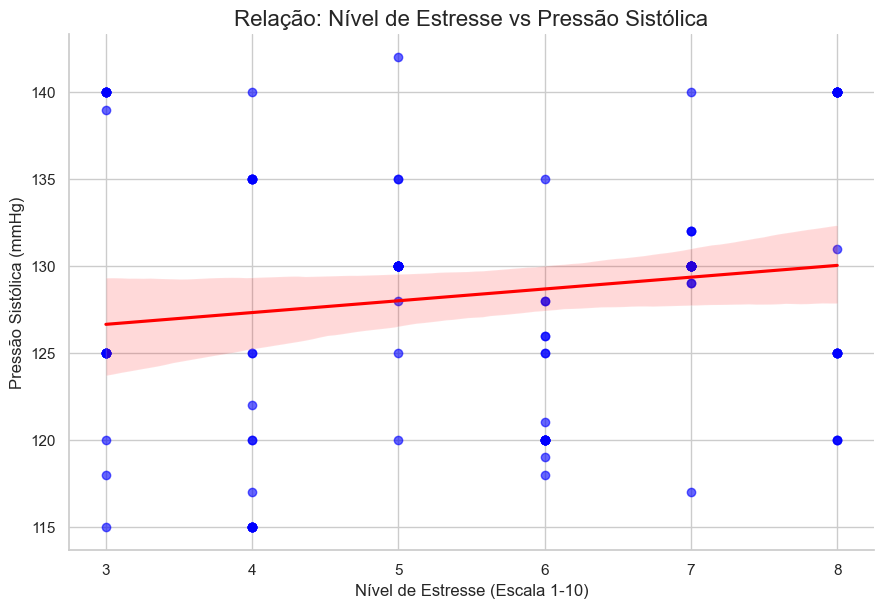

In [97]:
sns.lmplot(data=df, 
           x='Stress Level', 
           y='Systolic_BP', 
           height=6, 
           aspect=1.5, 
           line_kws={'color': 'red'}, 
           scatter_kws={'alpha': 0.6, 'color': 'blue'})


plt.title('Relação: Nível de Estresse vs Pressão Sistólica', fontsize=16)
plt.xlabel('Nível de Estresse (Escala 1-10)', fontsize=12)
plt.ylabel('Pressão Sistólica (mmHg)', fontsize=12)

plt.show()

C:\Users\caior\AppData\Local\Temp\ipykernel_17264\1942352947.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Quality of Sleep', palette="pastel")


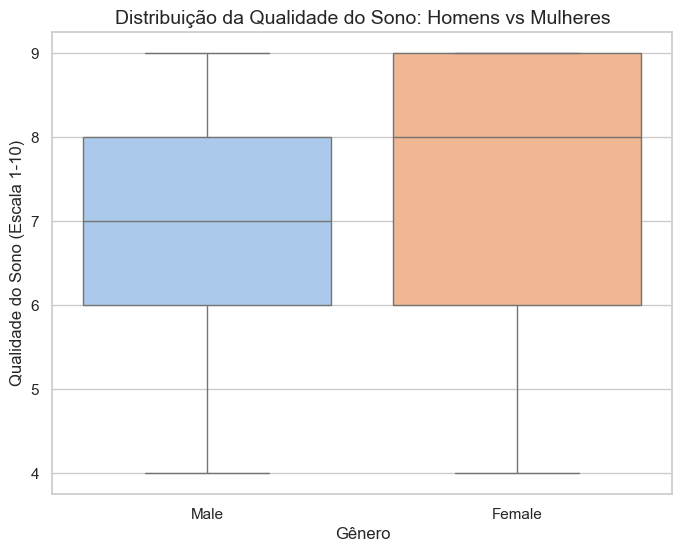

In [98]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Gender', y='Quality of Sleep', palette="pastel")

plt.title('Distribuição da Qualidade do Sono: Homens vs Mulheres', fontsize=14)
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Qualidade do Sono (Escala 1-10)', fontsize=12)

plt.show()

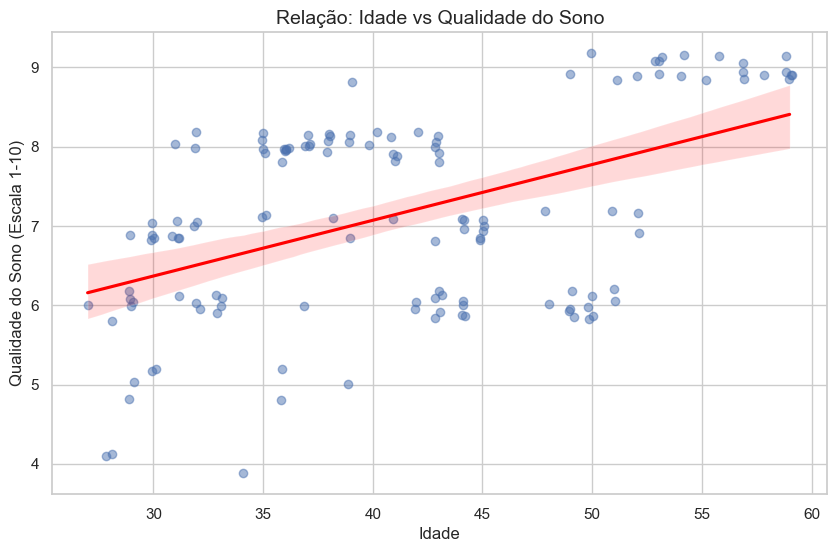

In [99]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df, 
            x='Age', 
            y='Quality of Sleep', 
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'},
            x_jitter=0.2, 
            y_jitter=0.2)


plt.title('Relação: Idade vs Qualidade do Sono', fontsize=14)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Qualidade do Sono (Escala 1-10)', fontsize=12)

plt.show()

C:\Users\caior\AppData\Local\Temp\ipykernel_17264\1567960478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sleep Disorder', y='Systolic_BP', palette="Reds")


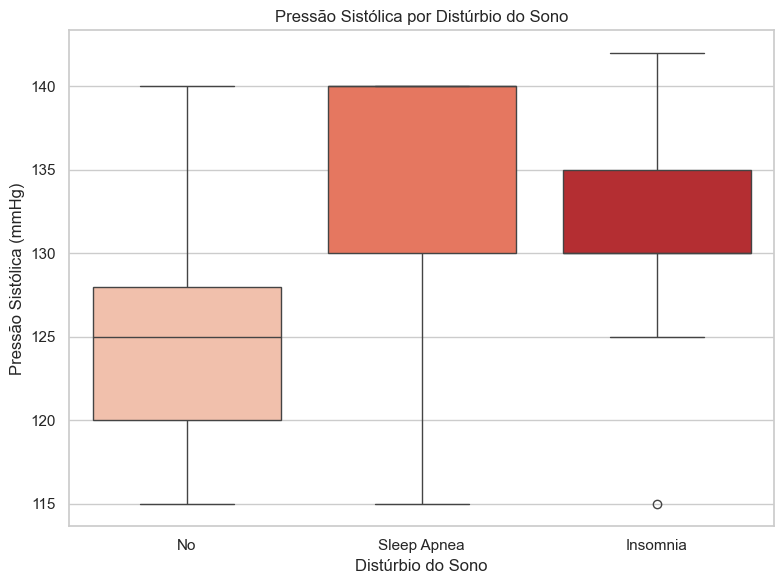

In [100]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Sleep Disorder', y='Systolic_BP', palette="Reds")

plt.title('Pressão Sistólica por Distúrbio do Sono')
plt.xlabel('Distúrbio do Sono')
plt.ylabel('Pressão Sistólica (mmHg)')
plt.tight_layout()
plt.show()

C:\Users\caior\AppData\Local\Temp\ipykernel_17264\2250343206.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sleep Disorder', y='Age', palette="Set2")


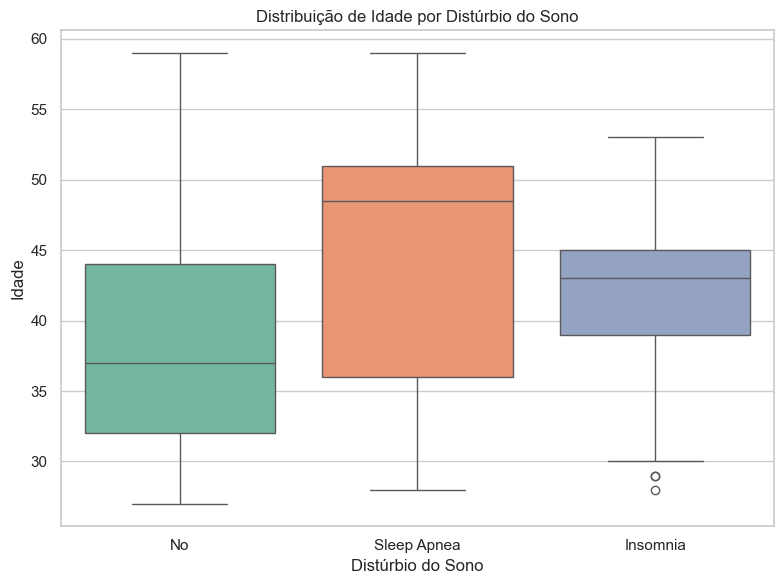

In [101]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Sleep Disorder', y='Age', palette="Set2")

plt.title('Distribuição de Idade por Distúrbio do Sono')
plt.xlabel('Distúrbio do Sono')
plt.ylabel('Idade')
plt.tight_layout()
plt.show()

C:\Users\caior\AppData\Local\Temp\ipykernel_17264\1132122506.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sleep Disorder', y='Physical Activity Level', palette="Blues", errorbar=None)


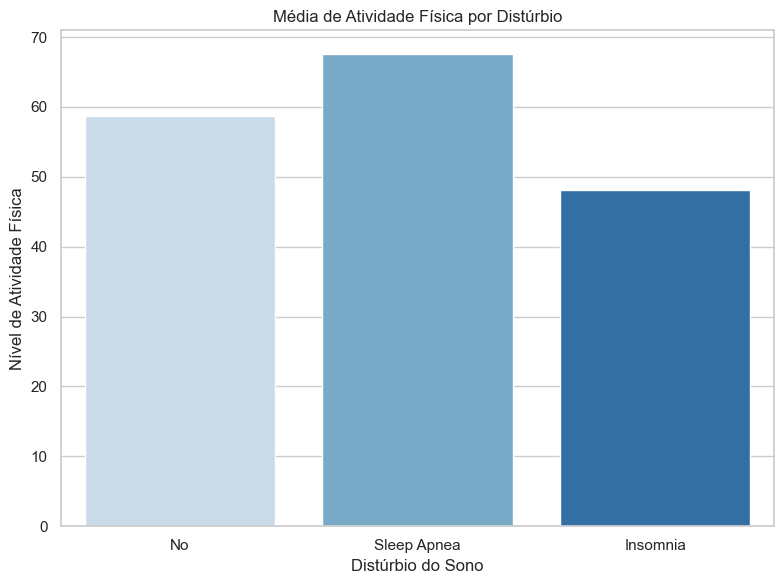

In [102]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Sleep Disorder', y='Physical Activity Level', palette="Blues", errorbar=None)

plt.title('Média de Atividade Física por Distúrbio')
plt.xlabel('Distúrbio do Sono')
plt.ylabel('Nível de Atividade Física')
plt.tight_layout()
plt.show()

#### Insights

1. A correlação entre a pressão sistólica e a pressão diastólica é muito próxima de 1, então eles carregam a mesma informação.
2. A pressão alta está ligada a um alto nível de estresse.
3. Em geral, as mulheres tem uma qualidade do sono maior que os homens.
4. Existe uma tendência da qualidade do sono melhorar com a idade.
5. Pessoas com pressão alta tem grandes chances de ter algum distúrbio do sono.
6. Problemas no sono tendem a aparecer nos mais velhos.
7. Pessoas com Apneia tem, em média, um maior nível de atividade física, enquanto pessoas com insônia tem a menor média.

### Modelo preditivo

=== Resultados da Validação Cruzada (5 Folds) ===
Scores Individuais: [0.75555556 0.64444444 0.66666667 0.67460317 0.81746032]
Recall Médio: 71.17%
Desvio Padrão: 6.49%

Acurácia no Teste (Single Split): 0.70

Relatório de Classificação:
              precision    recall  f1-score   support

    Insomnia       0.57      0.67      0.62         6
          No       0.75      0.80      0.77        15
 Sleep Apnea       0.75      0.50      0.60         6

    accuracy                           0.70        27
   macro avg       0.69      0.66      0.66        27
weighted avg       0.71      0.70      0.70        27



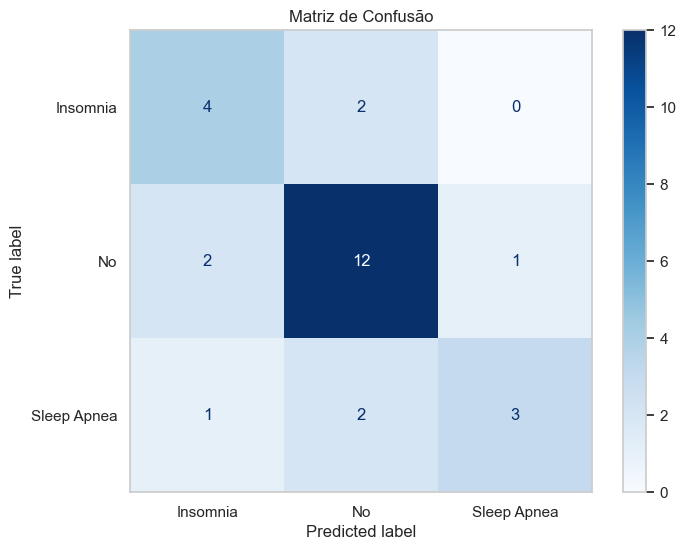

In [208]:
df = pd.read_csv('cleaned_health_data.csv')

# One-Hot Encoding
categorical_cols = ['Gender', 'BMI Category']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Seleção de variáveis
X = df_encoded.drop(['Sleep Disorder', 'Diastolic_BP',
                     'Quality of Sleep', 'Stress Level',
                     'Physical Activity Level', 'Occupation'], axis=1)
y = df_encoded['Sleep Disorder']

# Definição do Modelo
model = RandomForestClassifier(n_estimators=500, max_depth=3, random_state=42, class_weight='balanced')

# Validação Cruzada

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=718)
scores = cross_val_score(model, X, y, cv=cv, scoring='recall_macro')

print("=== Resultados da Validação Cruzada (5 Folds) ===")
print(f"Scores Individuais: {scores}")
print(f"Recall Médio: {scores.mean():.2%}")
print(f"Desvio Padrão: {scores.std():.2%}")
print("================================================\n")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model.fit(X_train, y_train)

# Avaliação Simples
y_pred = model.predict(X_test)

print(f"Acurácia no Teste (Single Split): {accuracy_score(y_test, y_pred):.2f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
ax.grid(False)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Matriz de Confusão')
plt.show()